<a href="https://colab.research.google.com/github/naqia88/Datasets/blob/main/ID_15982(Naqia_Firdous).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Direct download URL
file_id = "1p8H6UXSpWsbksFUuisKWYMd6TwHR8mjV"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Load into pandas DataFrame
df = pd.read_csv(url)

# Inspect first rows
print("Loaded dataset with shape:", df.shape)
print(df.head())


Loaded dataset with shape: (299, 13)
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1  

In [ ]:
male_percent = (df['sex'] == 1).mean() * 100
female_percent = (df['sex'] == 0).mean() * 100

print(f"Male: {male_percent:.2f}%")
print(f"Female: {female_percent:.2f}%")

Male: 64.88%
Female: 35.12%


In [ ]:
# Step 3: Basic information about dataset
print("Shape of dataset:", df.shape)      # Rows x Columns
print(df.info())                          # Column names, non-null counts, data types
print(df.describe())                      # Summary statistics for numeric columns
print(df.columns)                          # List all columns

Shape of dataset: (299, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


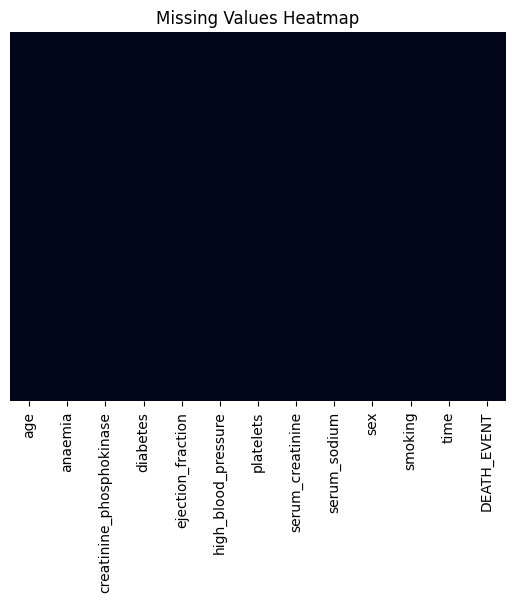

In [ ]:
# Step 4: Check for missing values
print(df.isnull().sum())

# Optional: Visualize missing values
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
# Step 5: Data type analysis
print(df.dtypes)
# Convert categorical columns to 'category' type if needed
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].astype('category')


age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


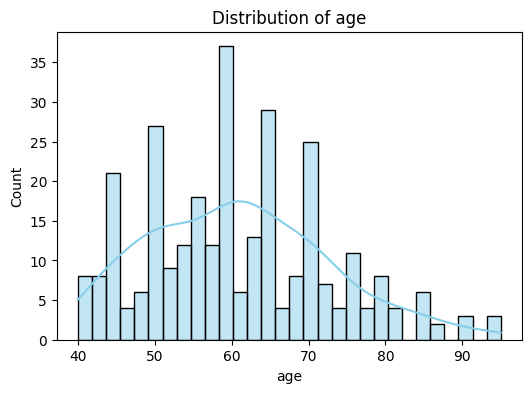

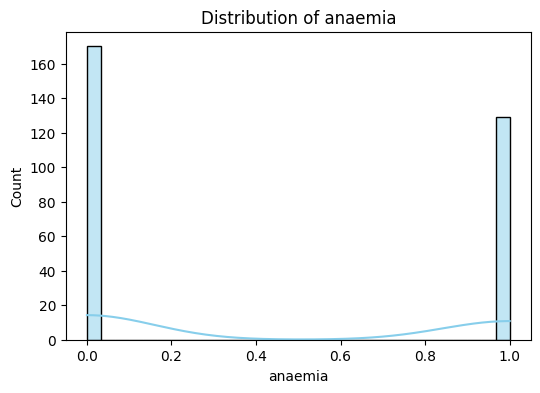

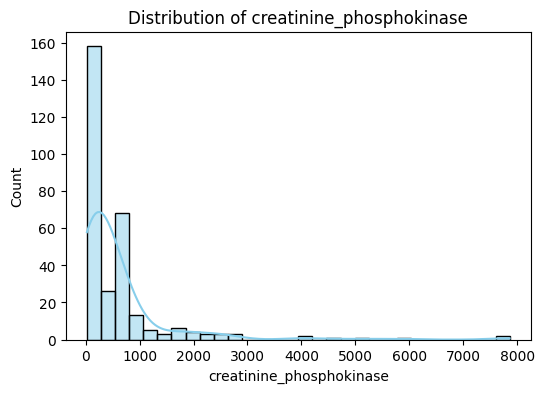

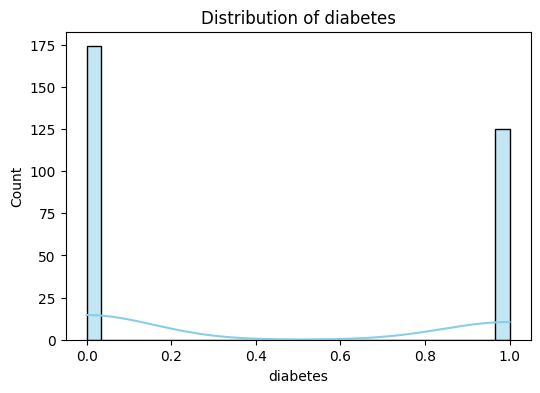

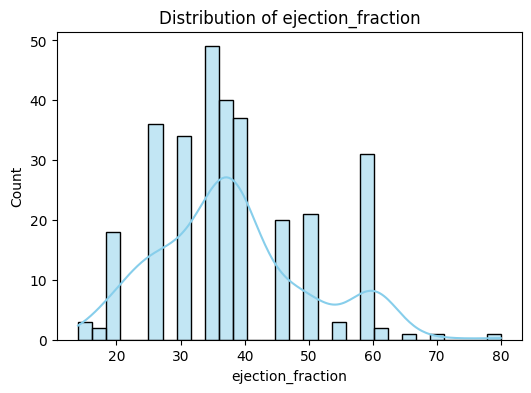

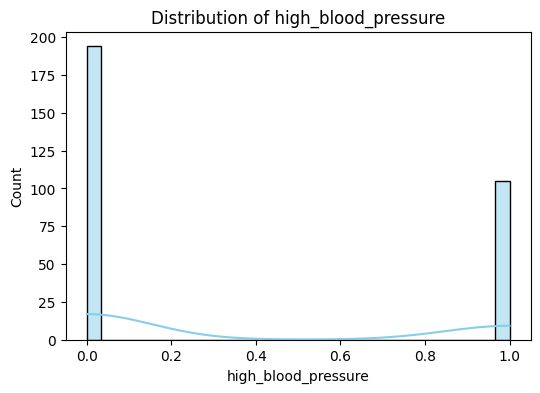

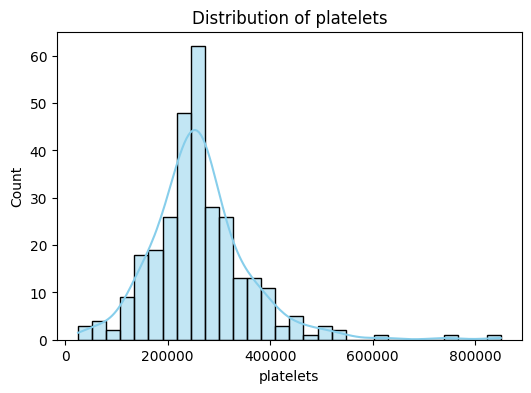

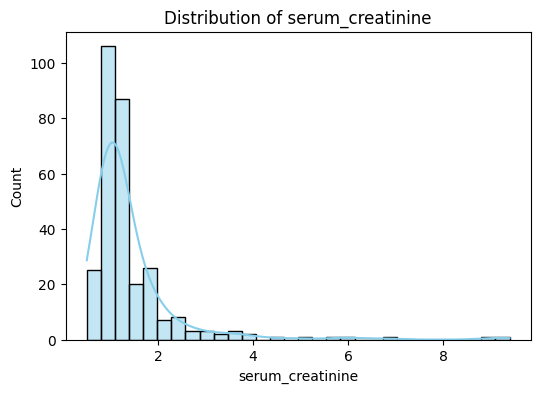

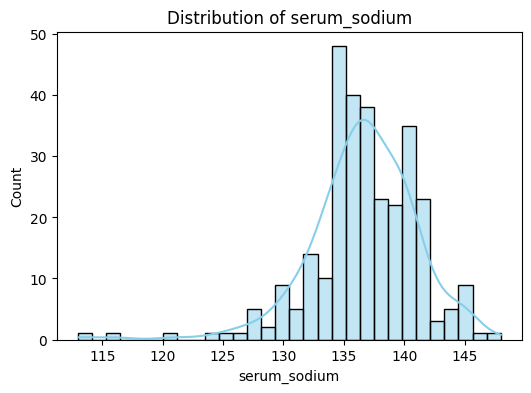

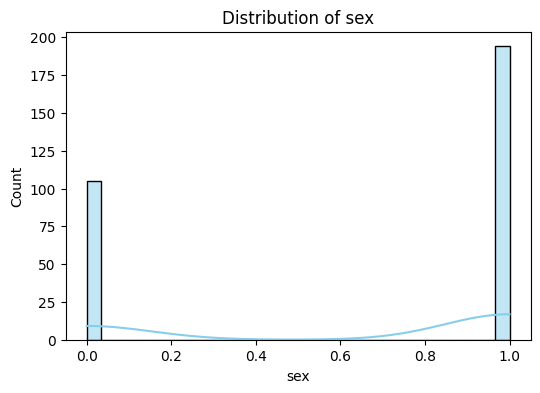

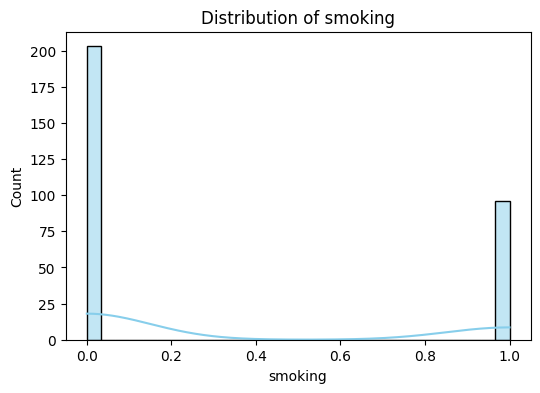

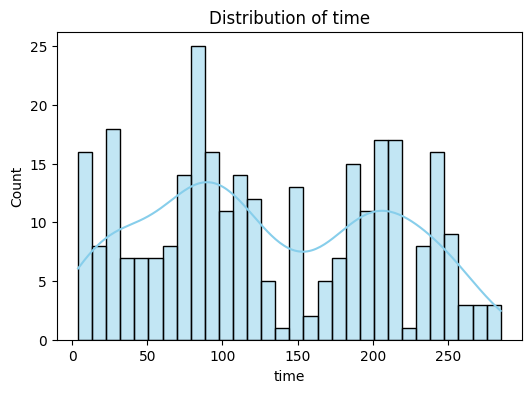

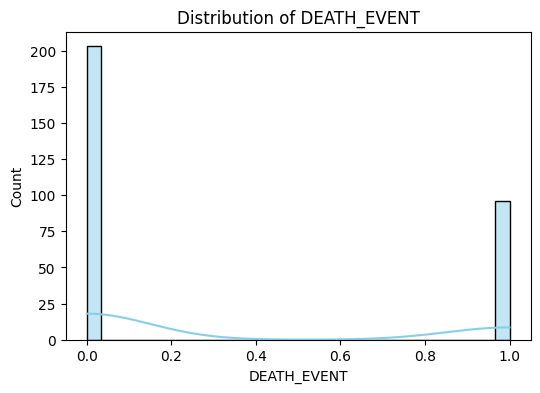

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Step 6: Univariate analysis
# Numeric features distribution
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

# Categorical features distribution
categorical_cols = df.select_dtypes(include='category').columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.show()


                               age   anaemia  creatinine_phosphokinase  \
age                       1.000000  0.088006                 -0.081584   
anaemia                   0.088006  1.000000                 -0.190741   
creatinine_phosphokinase -0.081584 -0.190741                  1.000000   
diabetes                 -0.101012 -0.012729                 -0.009639   
ejection_fraction         0.060098  0.031557                 -0.044080   
high_blood_pressure       0.093289  0.038182                 -0.070590   
platelets                -0.052354 -0.043786                  0.024463   
serum_creatinine          0.159187  0.052174                 -0.016408   
serum_sodium             -0.045966  0.041882                  0.059550   
sex                       0.065430 -0.094769                  0.079791   
smoking                   0.018668 -0.107290                  0.002421   
time                     -0.224068 -0.141414                 -0.009346   
DEATH_EVENT               0.253729  0.

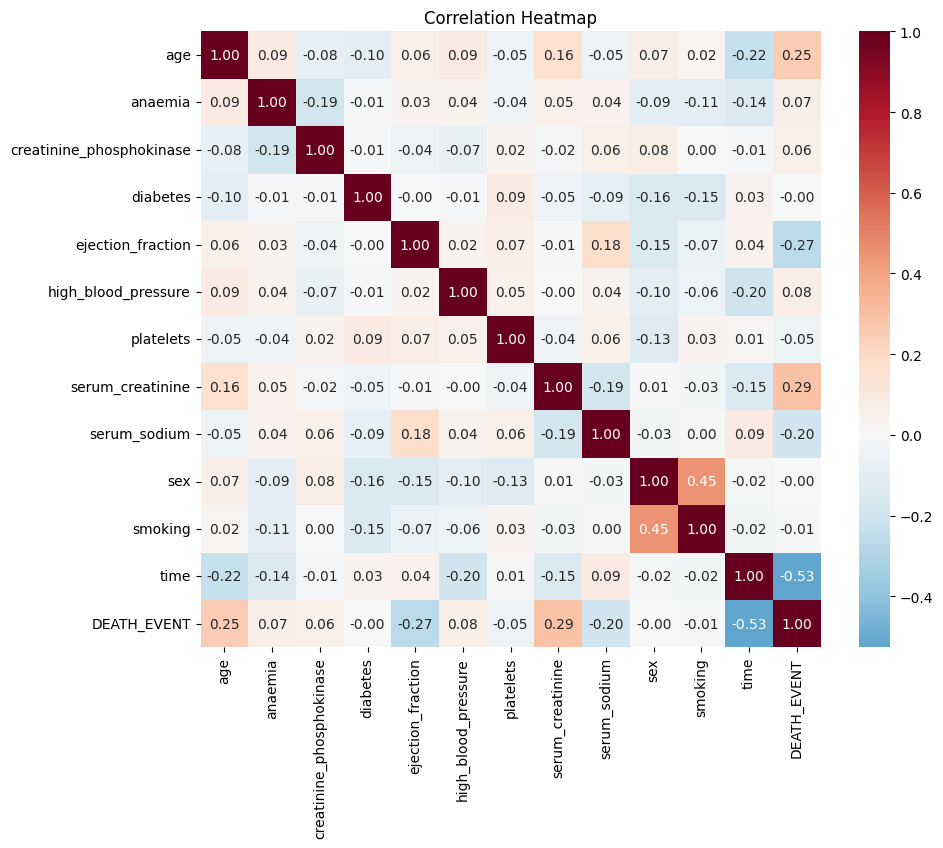

In [ ]:
# Step 7: Correlation analysis (numeric features)
corr_matrix = df.corr()

# Display correlation matrix
print(corr_matrix)

# Heatmap of correlations
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Correlation Heatmap")
plt.show()

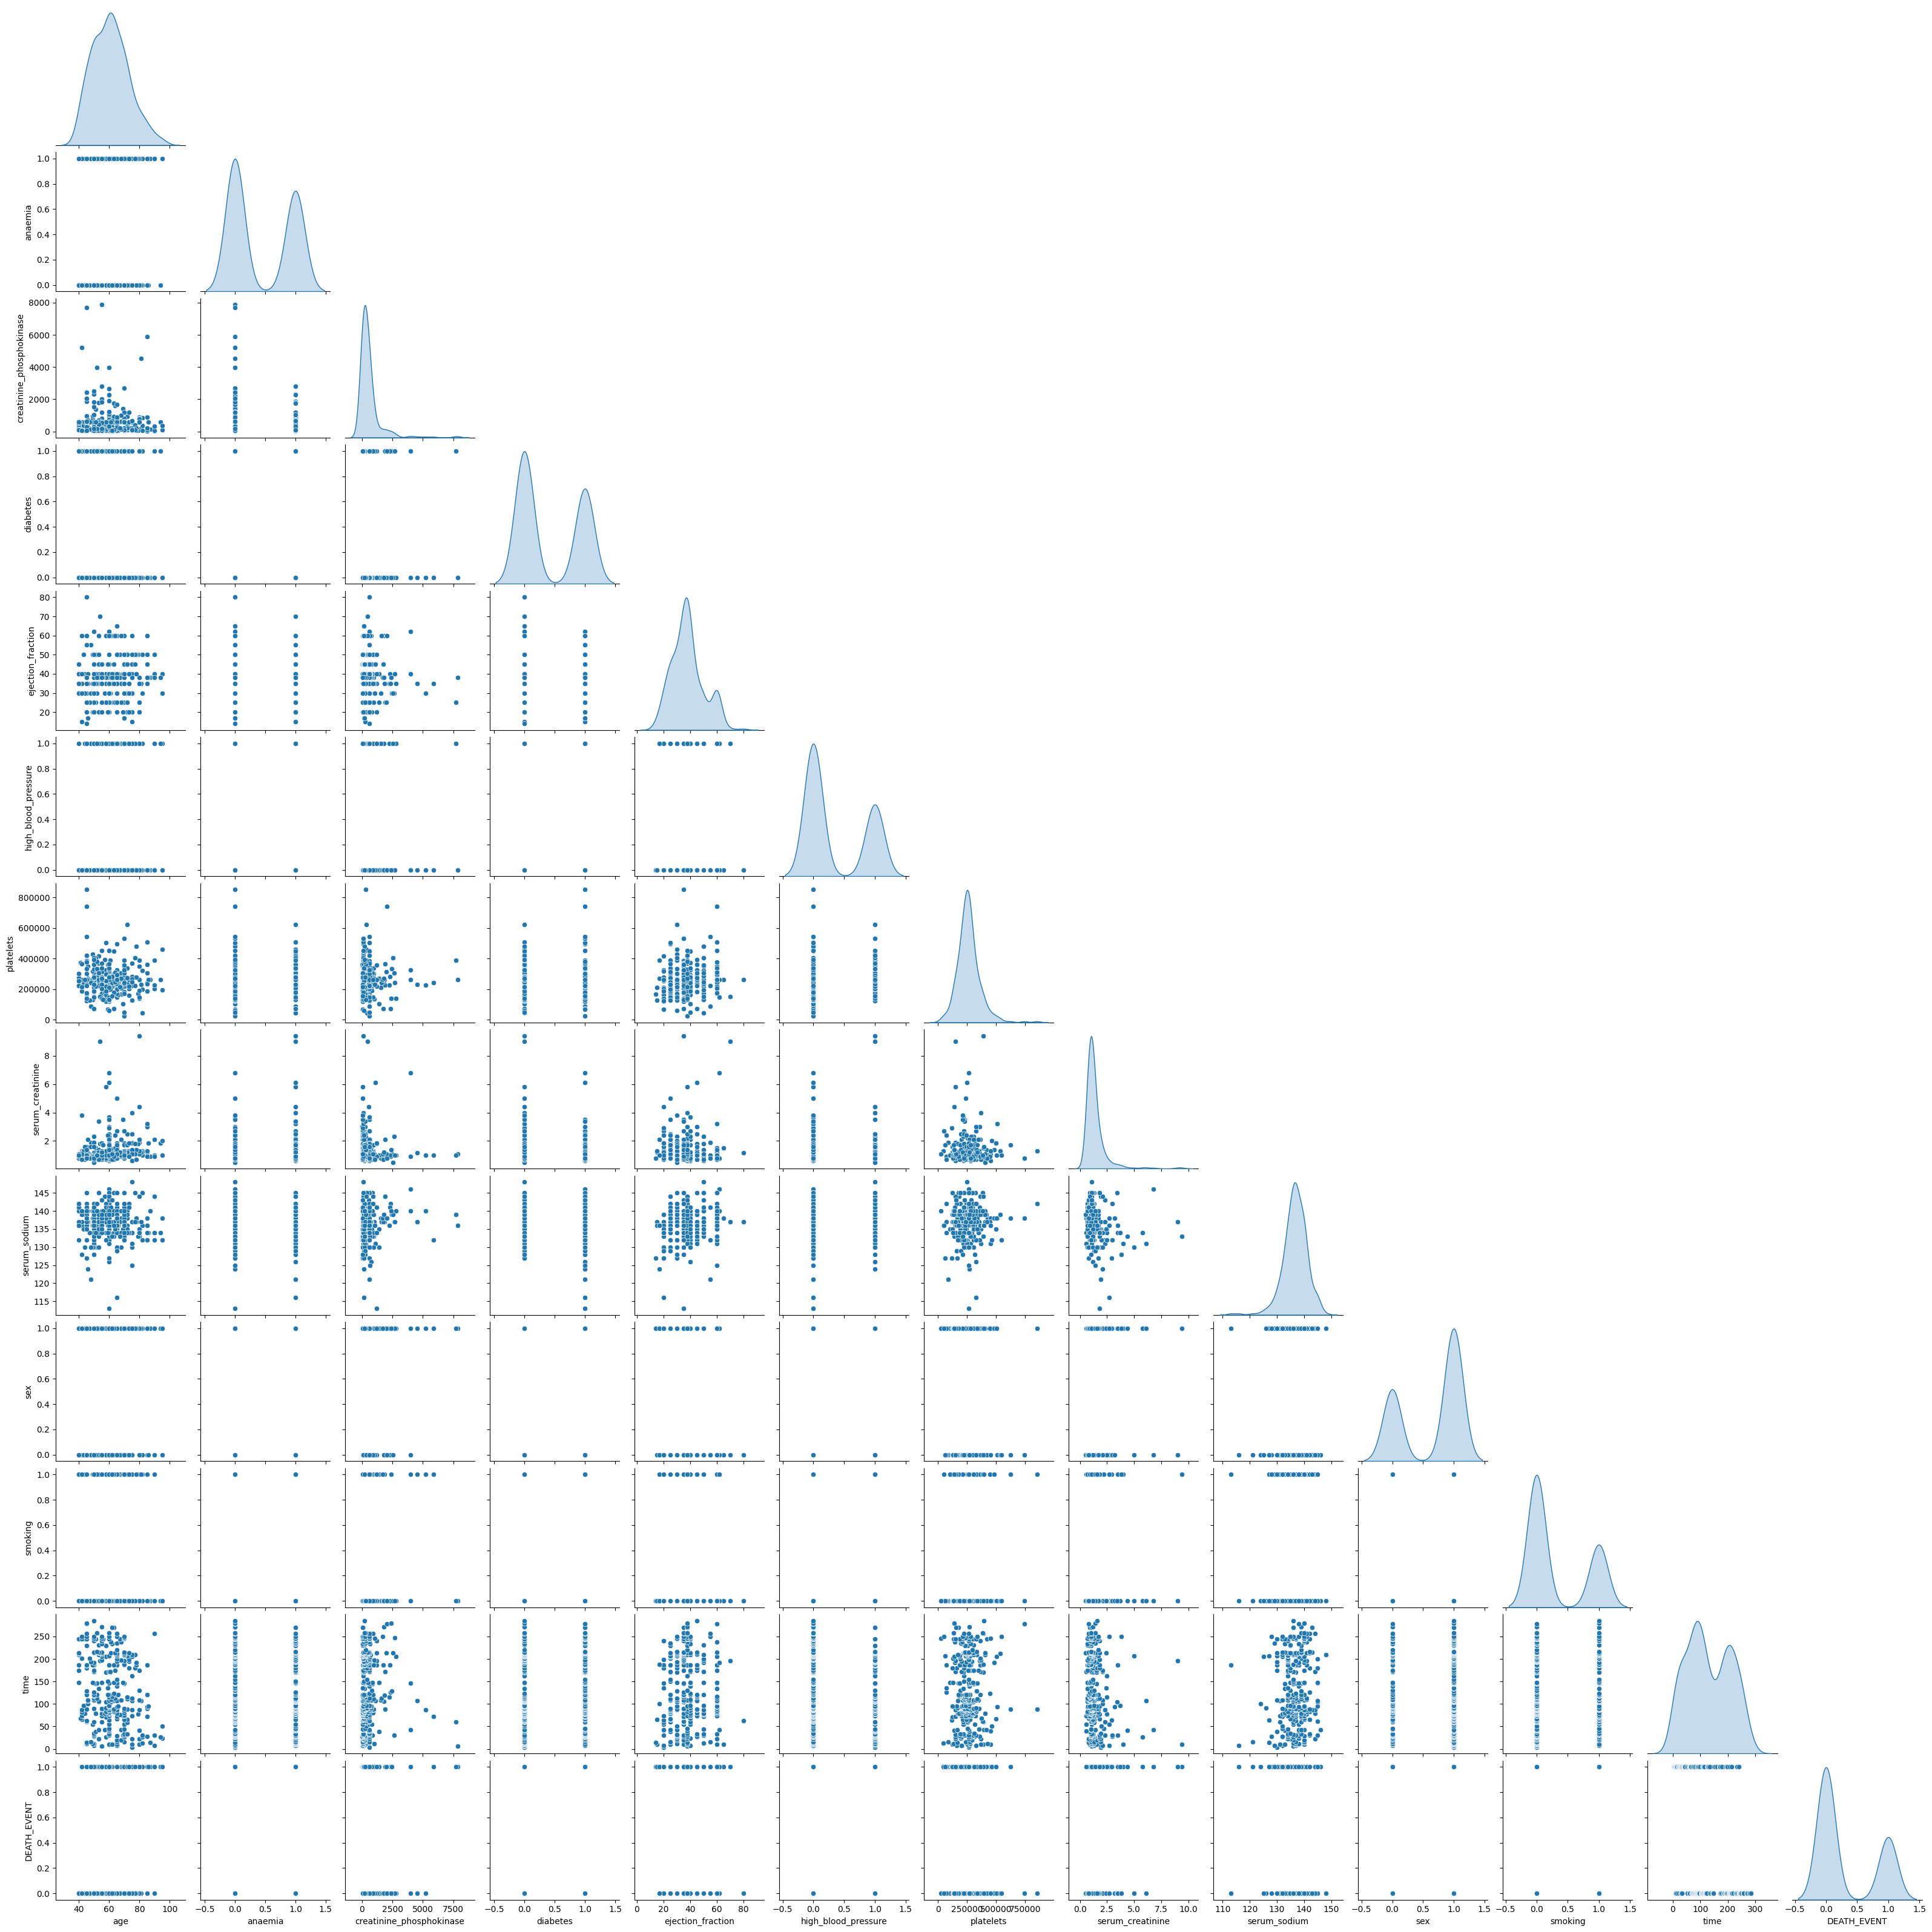

In [ ]:
# Step 8: Pairwise relationships (scatterplots)
# Only for numeric features
sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True)
plt.show()

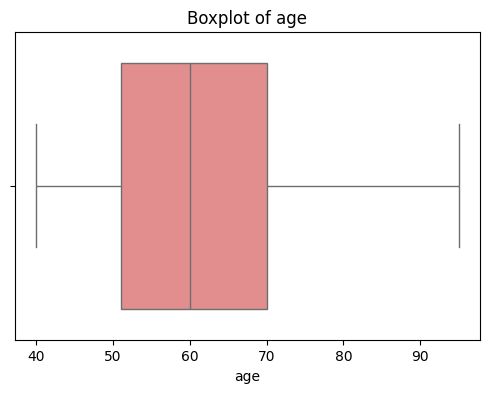

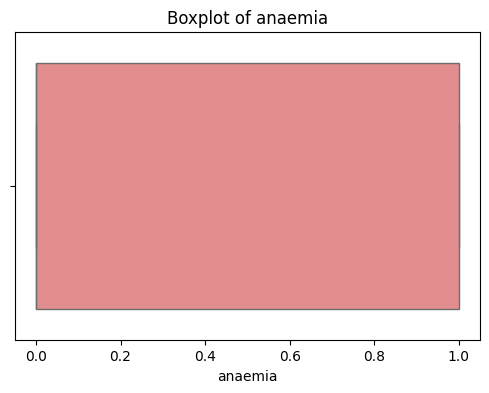

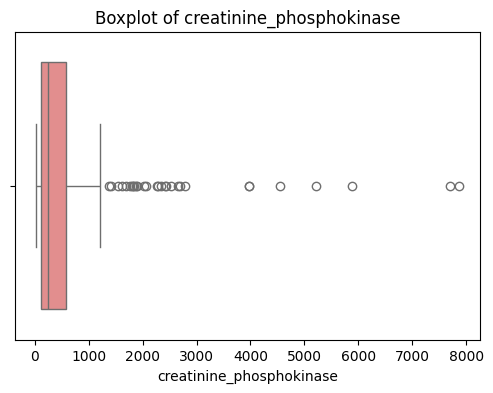

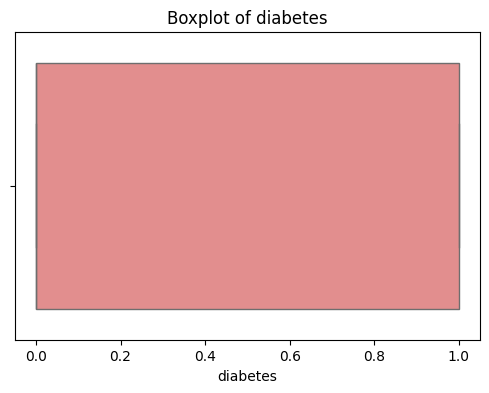

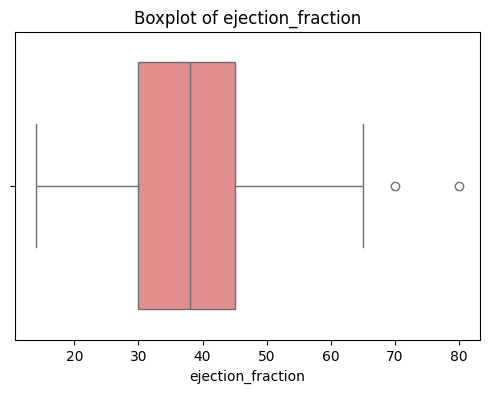

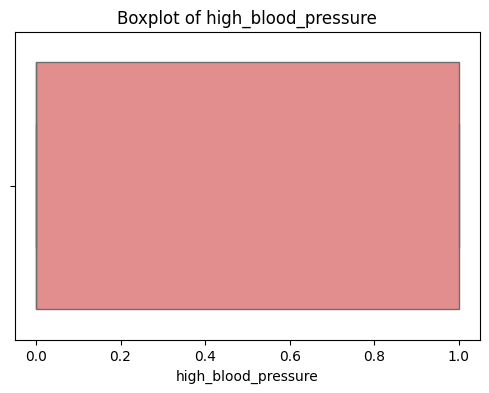

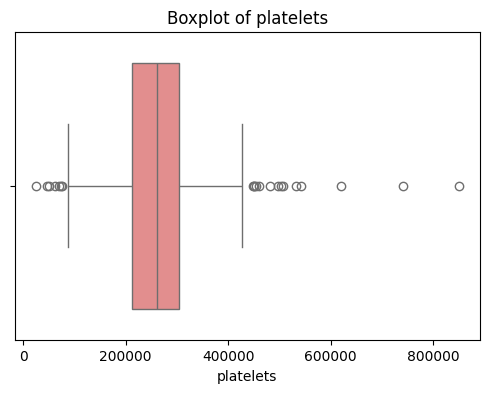

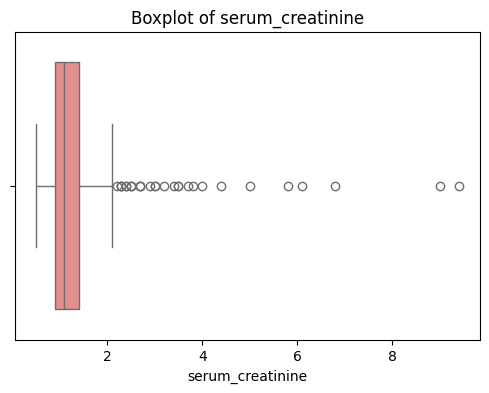

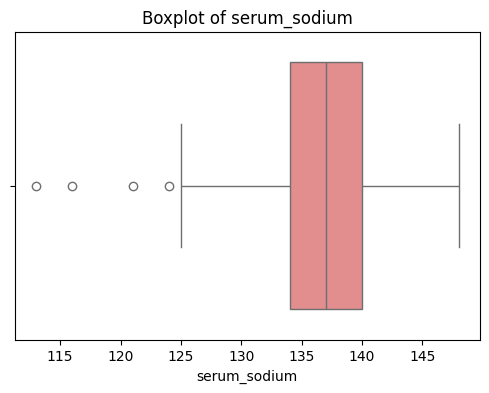

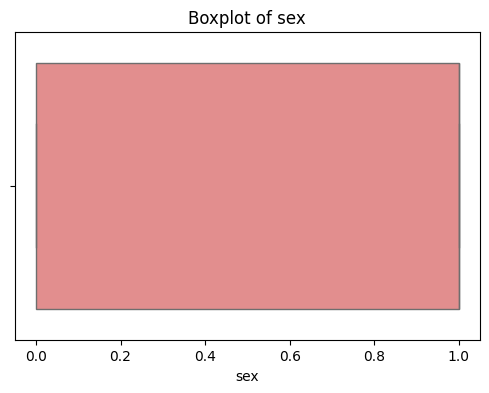

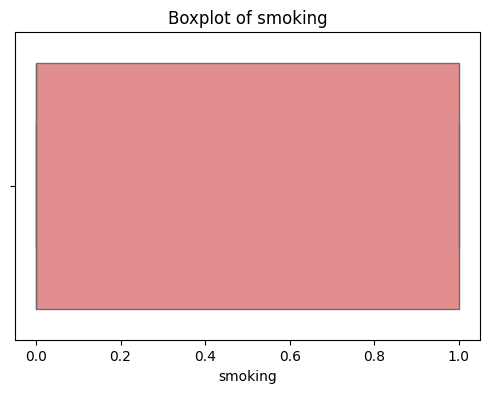

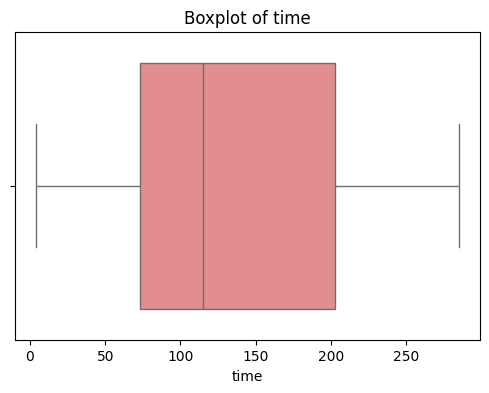

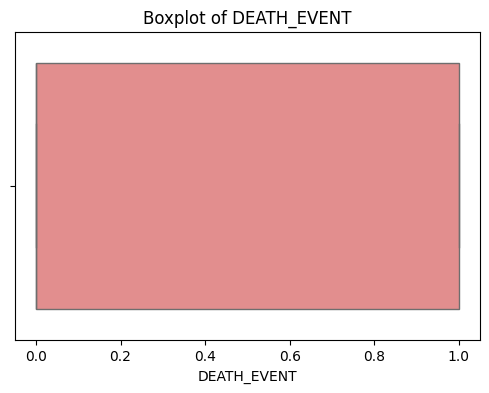

In [ ]:
# Step 9: Outlier detection using boxplots
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
# Step 10: Feature analysis & insights
# Example: Group by a categorical feature and get mean of numeric features
# Replace 'categorical_column' with actual column name
if len(categorical_cols) > 0:
    col = categorical_cols[0]
    print(df.groupby(col)[numeric_cols].mean())

In [ ]:
# Step 11: Save cleaned dataset (optional)
df.to_csv("cleaned_dataset.csv", index=False)


In [ ]:
# Features (X) = all numeric columns except target
X = df.drop('DEATH_EVENT', axis=1)

# Target (y) = DEATH_EVENT column
y = df['DEATH_EVENT']

from sklearn.model_selection import train_test_split
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

# Initialize model
model = LogisticRegression(max_iter=5000)

# Train the model
model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions on test set
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Detailed report
print("Classification Report:\n", classification_report(y_test, y_pred))
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)


Accuracy: 0.8
Confusion Matrix:
 [[33  2]
 [10 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.94      0.85        35
           1       0.88      0.60      0.71        25

    accuracy                           0.80        60
   macro avg       0.82      0.77      0.78        60
weighted avg       0.82      0.80      0.79        60

                     Feature  Coefficient
7           serum_creatinine     0.792780
3                   diabetes     0.452511
10                   smoking     0.090046
0                        age     0.061981
8               serum_sodium     0.000199
2   creatinine_phosphokinase     0.000112
6                  platelets    -0.000002
11                      time    -0.022250
4          ejection_fraction    -0.079718
5        high_blood_pressure    -0.119231
1                    anaemia    -0.165845
9                        sex    -0.584159


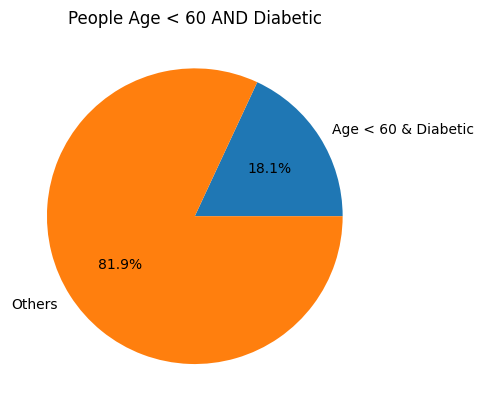

In [ ]:
import matplotlib.pyplot as plt

# Condition: Age < 60 AND Diabetes == 1
condition_percent = ((df['age'] < 60) & (df['diabetes'] == 1)).mean() * 100
remaining_percent = 100 - condition_percent

labels = ['Age < 60 & Diabetic', 'Others']
sizes = [condition_percent, remaining_percent]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('People Age < 60 AND Diabetic')
plt.show()




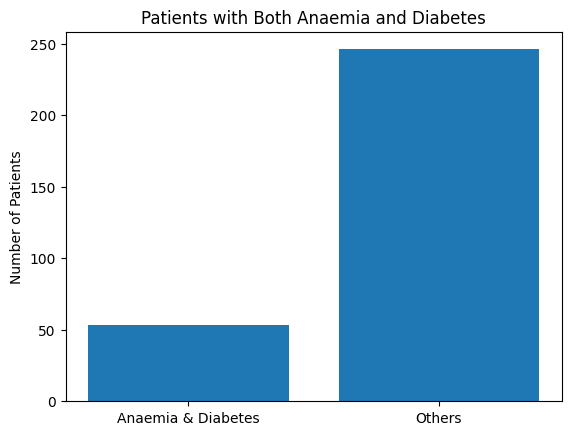

In [ ]:
import matplotlib.pyplot as plt

# Count people with both anaemia and diabetes
both_count = ((df['anaemia'] == 1) & (df['diabetes'] == 1)).sum()
others_count = len(df) - both_count

labels = ['Anaemia & Diabetes', 'Others']
values = [both_count, others_count]

plt.bar(labels, values)
plt.title('Patients with Both Anaemia and Diabetes')
plt.ylabel('Number of Patients')
plt.show()


Deaths by Condition:
Anaemia                46
Diabetes               40
High Blood Pressure    39
Smoking                30
dtype: int64


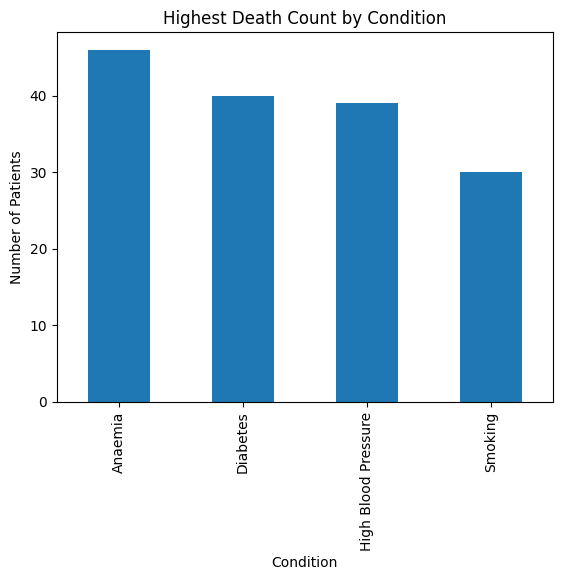

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter only patients who died
died_df = df[df['DEATH_EVENT'] == 1]

# Count deaths per condition
death_counts = {
    'Anaemia': died_df['anaemia'].sum(),
    'Diabetes': died_df['diabetes'].sum(),
    'High Blood Pressure': died_df['high_blood_pressure'].sum(),
    'Smoking': died_df['smoking'].sum()
}

# Convert to Series for easy plotting
death_series = pd.Series(death_counts)

print("Deaths by Condition:")
print(death_series)

# Bar Graph
plt.figure()
death_series.plot(kind='bar')
plt.title('Highest Death Count by Condition')
plt.ylabel('Number of Patients')
plt.xlabel('Condition')
plt.show()


Death Rate (%) per Condition:
anaemia                35.658915
diabetes               32.000000
high_blood_pressure    37.142857
smoking                31.250000
dtype: float64


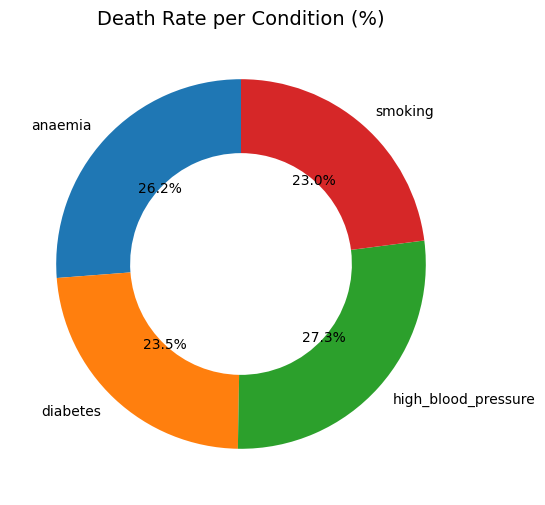

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List of disease/risk columns
conditions = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

# Calculate death rate per condition
death_rates = {}
for cond in conditions:
    total_with_condition = df[df[cond] == 1]
    deaths_with_condition = total_with_condition['DEATH_EVENT'].sum()
    rate = (deaths_with_condition / len(total_with_condition)) * 100
    death_rates[cond] = rate

# Convert to Series
death_rate_series = pd.Series(death_rates)

print("Death Rate (%) per Condition:")
print(death_rate_series)

# ---- Donut Chart -
fig, ax = plt.subplots(figsize=(6,6))

# Create the donut chart
wedges, texts, autotexts = ax.pie(
    death_rate_series,
    labels=death_rate_series.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}  # width < 1 makes it a donut
)

# Optional: center circle style (already handled by width)
# centre_circle = plt.Circle((0,0),0.70,fc='white')
# fig.gca().add_artist(centre_circle)

ax.set_title('Death Rate per Condition (%)', fontsize=14)
plt.show()

Death Count per Medical Condition / Measurement:
anaemia                     46
creatinine_phosphokinase    34
diabetes                    40
ejection_fraction           19
high_blood_pressure         39
platelets                   26
serum_creatinine            47
serum_sodium                18
smoking                     30
dtype: int64


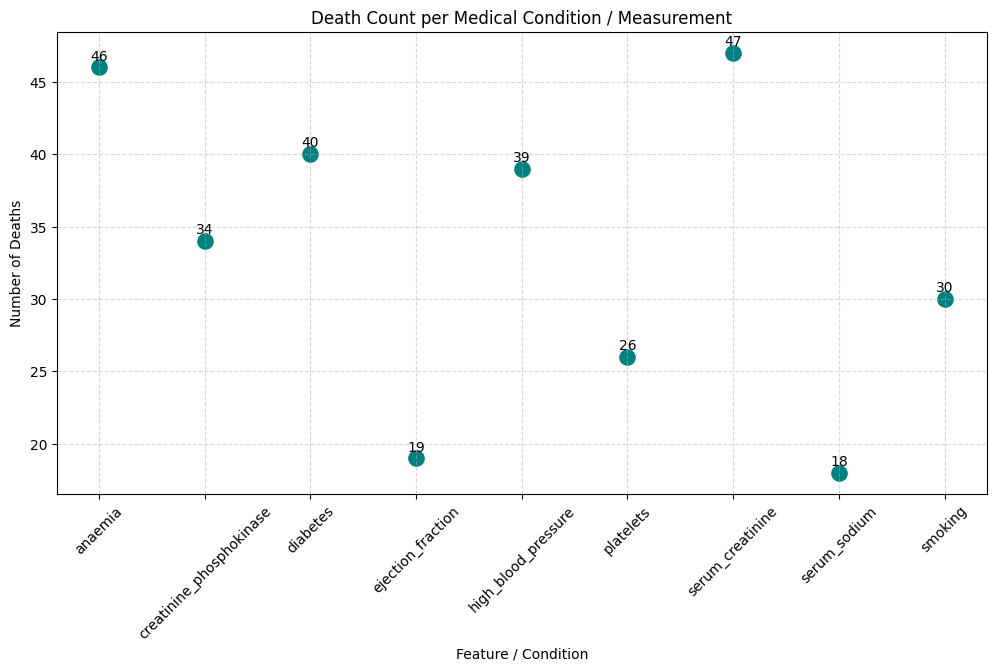

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# List of medical conditions / measurements
features = ['anaemia','creatinine_phosphokinase','diabetes',
            'ejection_fraction','high_blood_pressure','platelets',
            'serum_creatinine','serum_sodium','smoking']

death_counts = {}

for feat in features:
    if df[feat].nunique() <= 5:  # Binary / categorical features
        # Count deaths where feature = 1
        death_counts[feat] = df[df[feat] == 1]['DEATH_EVENT'].sum()
    else:  # Numeric features
        # Sum deaths for patients with highest quartile (top 25%) as proxy
        threshold = df[feat].quantile(0.75)
        death_counts[feat] = df[df[feat] >= threshold]['DEATH_EVENT'].sum()

# Convert to Series
death_series = pd.Series(death_counts)

print("Death Count per Medical Condition / Measurement:")
print(death_series)

# ---- Scatter Plot ----
plt.figure(figsize=(12,6))
plt.scatter(death_series.index, death_series.values, color='teal', s=120)

# Add data labels above each point
for i, value in enumerate(death_series.values):
    plt.text(i, value + 0.5, str(int(value)), ha='center', fontsize=10)

plt.title('Death Count per Medical Condition / Measurement')
plt.ylabel('Number of Deaths')
plt.xlabel('Feature / Condition')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


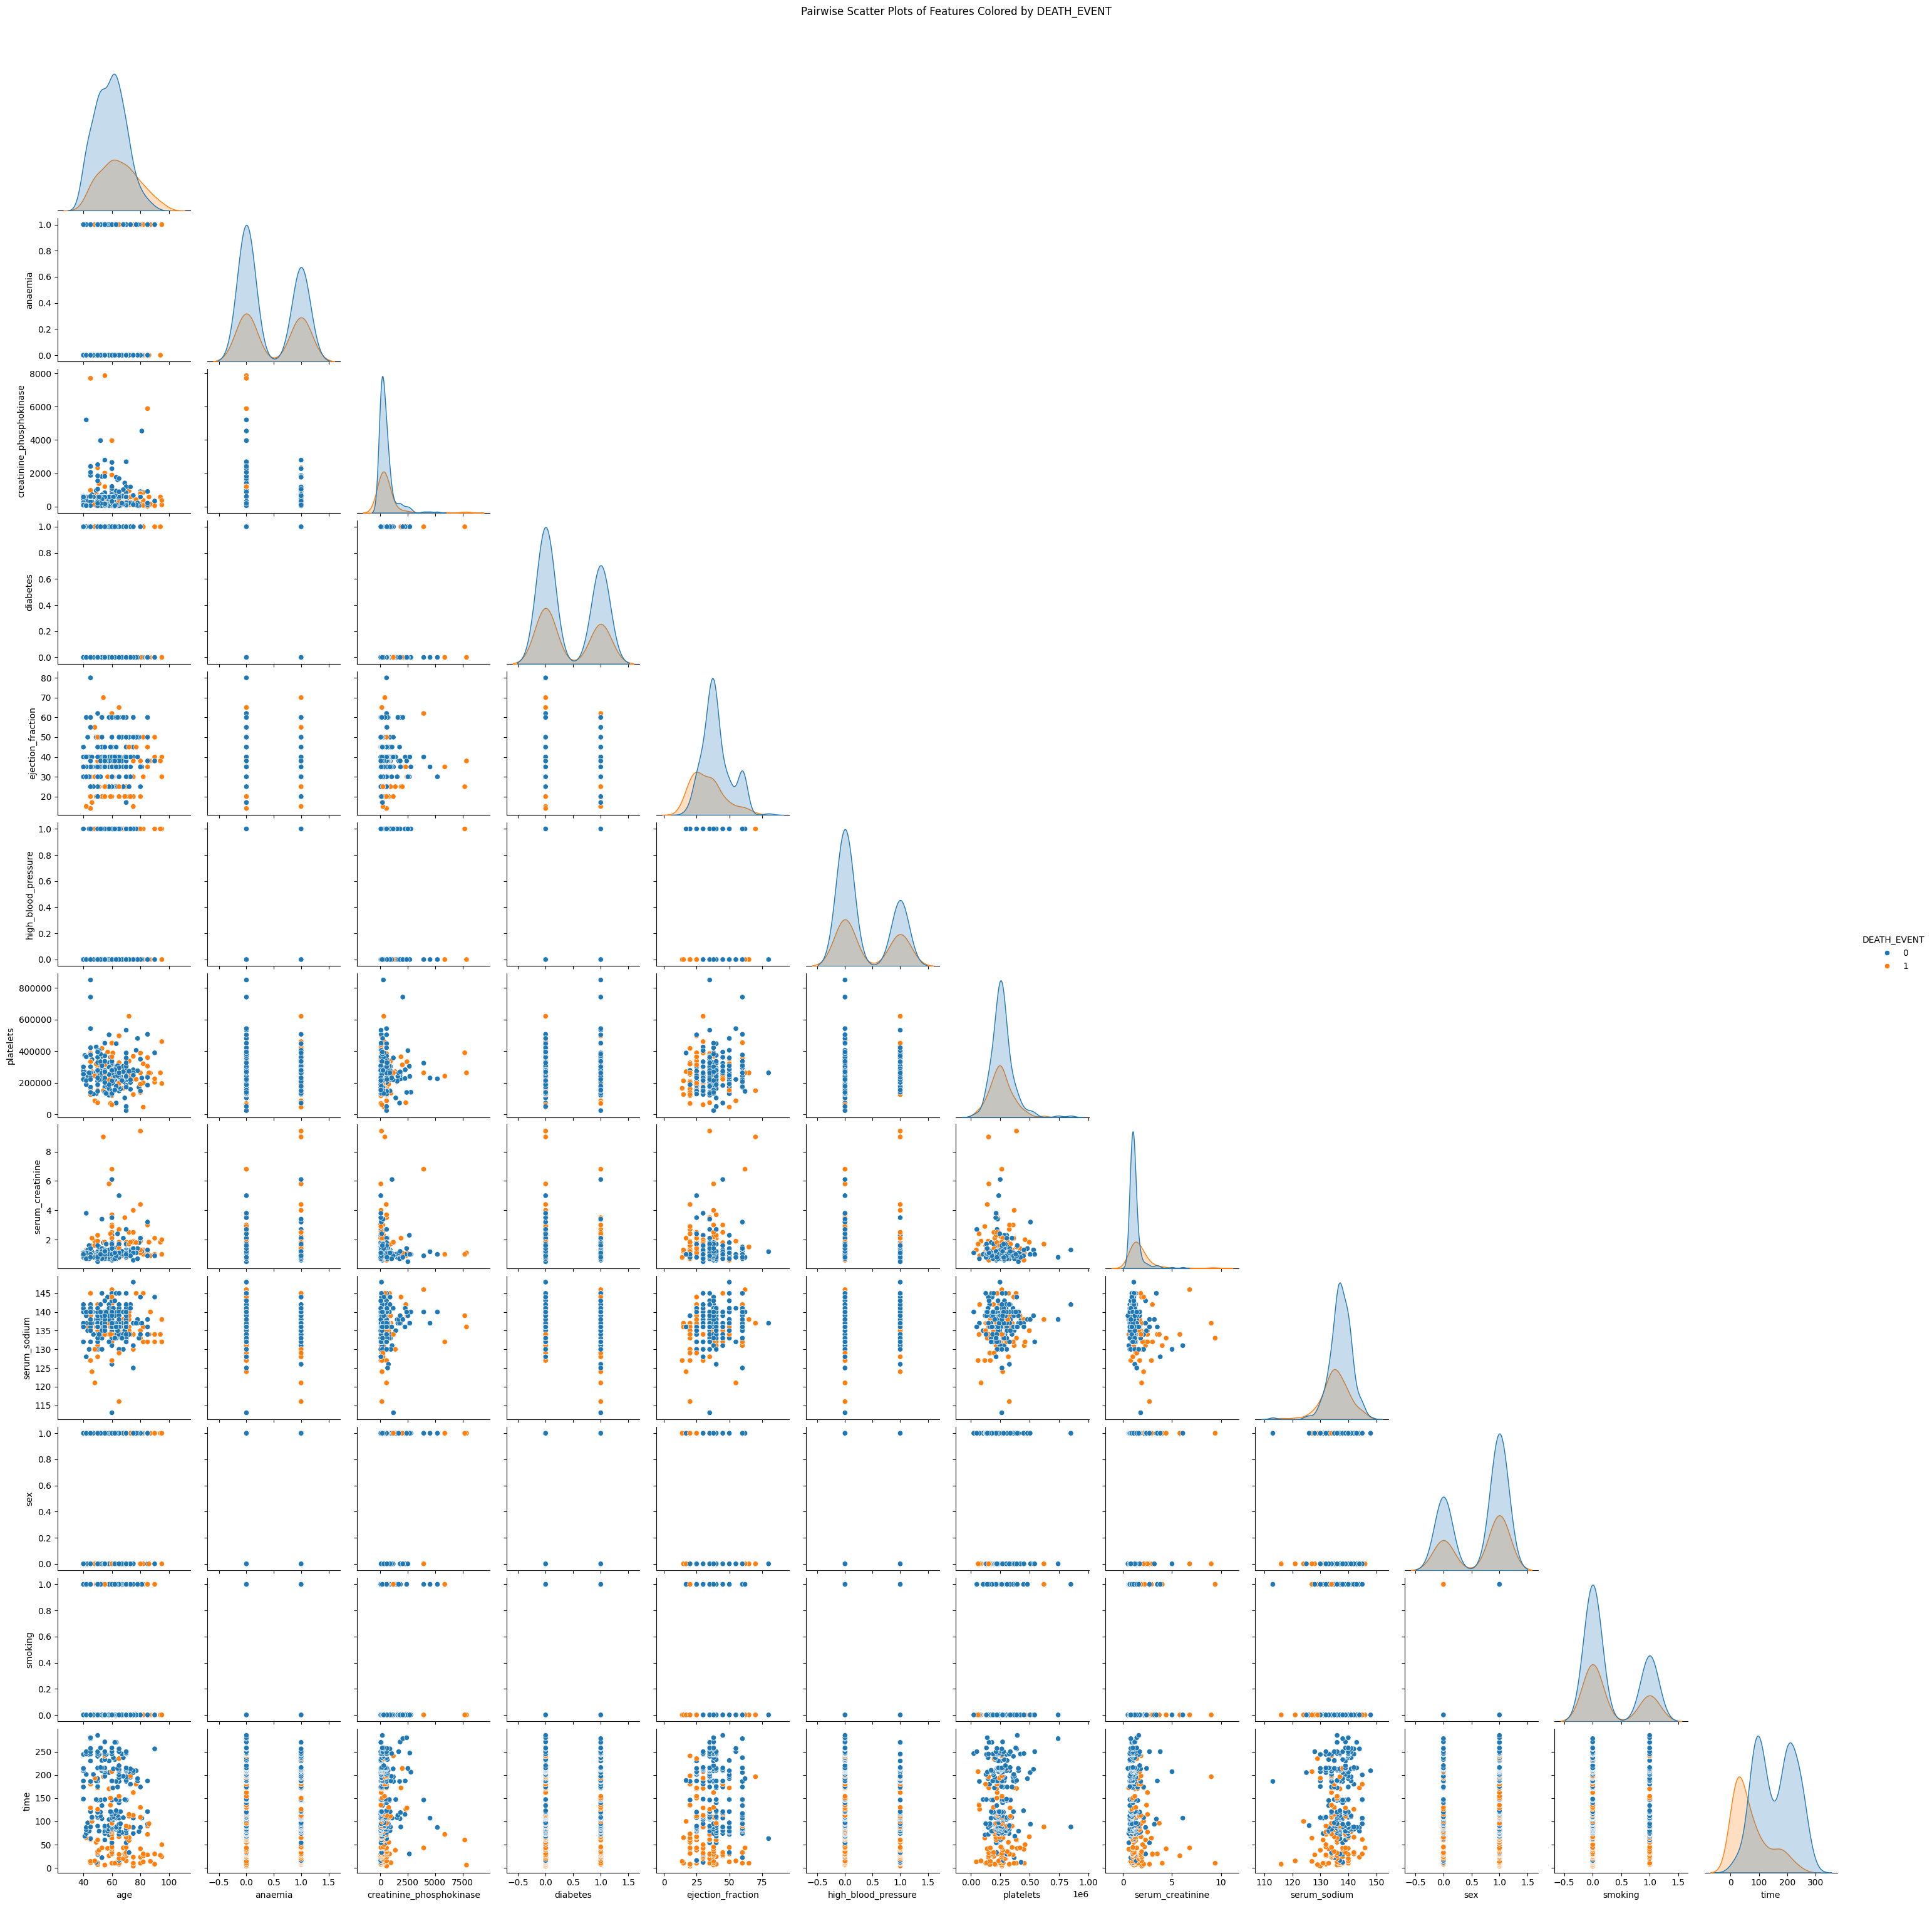

In [ ]:
import seaborn as sns

# Select numeric features
features = ['age','anaemia','creatinine_phosphokinase','diabetes',
            'ejection_fraction','high_blood_pressure','platelets',
            'serum_creatinine','serum_sodium','sex','smoking','time']

sns.pairplot(df[features + ['DEATH_EVENT']], hue='DEATH_EVENT', corner=True)
plt.suptitle('Pairwise Scatter Plots of Features Colored by DEATH_EVENT', y=1.02)
plt.show()
